In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="white")

def buscar_archivo(nombre):
    rutas = [os.path.join('csv', nombre), os.path.join('..', 'csv', nombre)]
    for r in rutas:
        if os.path.exists(r):
            return r
    return None

print("Configuración lista.")

Configuración lista.


In [ ]:
ruta = buscar_archivo('ArchivoC_Adm2025.csv')

if ruta:
    columnas_demre = {
        'PTJE_NEM': 'NEM',
        'PTJE_RANKING': 'RANKING',
        'CLEC_REG_ACTUAL': 'LENGUAJE',
        'MATE1_REG_ACTUAL': 'M1',
        'MATE2_REG_ACTUAL': 'M2',
        'CIEN_REG_ACTUAL': 'CIENCIAS'
    }
    
    df = pd.read_csv(ruta, sep=';', usecols=columnas_demre.keys(), low_memory=False)
    df = df.rename(columns=columnas_demre)
    
    # Convertir todo a formato numérico
    df = df.apply(pd.to_numeric, errors='coerce')
    
    df_analisis = df[(df > 0).all(axis=1)].dropna()
    
    print(f"Datos cargados: {len(df_analisis)} estudiantes leidos.")
else:
    print("Error: No se encontró el archivo en las rutas especificadas.")

Datos cargados: 85454 estudiantes listos para el análisis.


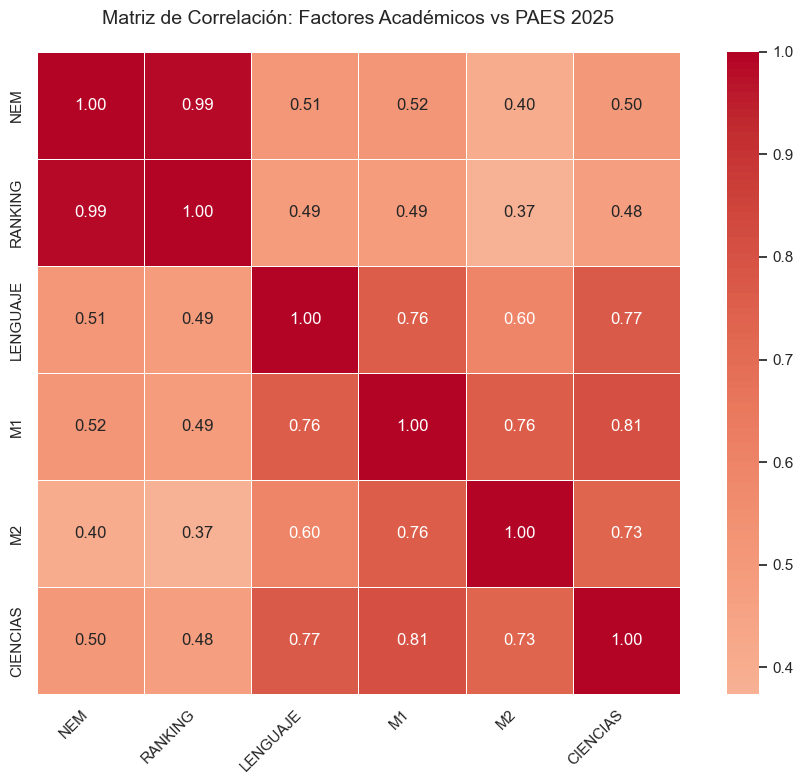

In [ ]:
# Calculamos la matriz de correlación
correlacion = df_analisis.corr()

plt.figure(figsize=(10, 8))


sns.heatmap(
    correlacion, 
    annot=True,       # Muestra los valores numéricos de Pearson
    fmt=".2f",        # Redondea a dos decimales
    cmap='coolwarm',  # Escala de color térmica
    center=0,         # El color blanco representa ausencia de relación
    square=True,      # Mantiene las celdas con forma cuadrada
    linewidths=.5     # Agrega una línea fina divisoria entre cuadros
)

plt.title('Matriz de Correlación: Factores Académicos vs PAES 2025', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()